<a href="https://colab.research.google.com/github/seom0323-web/Computational-Physics-Newman/blob/main/ComputationalPhysics(ODE2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,v):
  return v**2-x-5
def verlet(f,x,v,h):
  v+=0.5*h*f(x,v)
  x+=h*v
  v+=0.5*h*f(x,v)
  return x,v

a=0.0
b=50.0
h=0.001
t=np.arange(a,b,h)
x=np.zeros((len(t)))
v=np.zeros_like(x)
x[0]=1
v[0]=0

for i in range(len(t)-1):
  x[i+1],v[i+1]=verlet(f,x[i],v[i],h)

plt.plot(t,x)
plt.xlabel('t')
plt.ylabel('x')
plt.show()




In [ ]:
#공기저항이 있는 포물선 운동
import numpy as np
import matplotlib.pyplot as plt

R=0.08
d_air=1.22
C=0.47
m=1.0
g=9.8
theta=45.0*np.pi/180

def f(r,t):
  x,y,vx,vy=r[0],r[1],r[2],r[3]
  r=np.array([x,y,vx,vy],float)
  fx=vx #x의 속도
  fy=vy #y의 속도
  fx2=-((np.pi*R**2*d_air*C)/2*m)*fx*np.sqrt(fx**2+fy**2) #x의 가속도
  fy2=-g-((np.pi*R**2*d_air*C)/2*m)*fy*np.sqrt(fx**2+fy**2) #y의 가속도
  return np.array([fx,fy,fx2,fy2],float)

def RK4(f,r,t,h): #룽게쿠타 방법
  k1=h*f(r,t)
  k2=h*f(r+0.5*k1,t+0.5*h)
  k3=h*f(r+0.5*k2,t+0.5*h)
  k4=h*f(r+k3,t+h)
  r+=(k1+2*k2+2*k3+k4)/6
  return r

a=0.0
b=100.0
N=100000
h=(b-a)/N
tpoints=np.arange(a,b,h)
r=np.zeros((len(tpoints),4),float)
x=r[:,0]
y=r[:,1]
vx=r[:,2]
vy=r[:,3]
r[0]=np.array([0,0,+100*np.cos(theta),+100*np.sin(theta)],float)
for i in range(len(tpoints)-1):
  r[i+1]=RK4(f,r[i],tpoints[i],h)
  if r[:,1][i+1]<=0:
    break

plt.plot(r[:,0],r[:,1],'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Orbit of Trajectory with air resistance')
plt.show()






In [ ]:
from math import sin,pi
from numpy import empty,array,arange
from pylab import plot,show

g = 9.81
l = 0.1
theta0 = 179*pi/180

a = 0.0
b = 10.0
N = 100          # Number of "big steps"
H = (b-a)/N      # Size of "big steps"
delta = 1e-8     # Required position accuracy per unit time

def f(r):
    theta = r[0]
    omega = r[1]
    ftheta = omega
    fomega = -(g/l)*sin(theta)
    return array([ftheta,fomega],float)

tpoints = arange(a,b,H)
thetapoints = []
r = array([theta0,0.0],float)

# Do the "big steps" of size H
for t in tpoints:

    thetapoints.append(r[0])

    # Do one modified midpoint step to get things started
    n = 1
    r1 = r + 0.5*H*f(r)
    r2 = r + H*f(r1)

    # The array R1 stores the first row of the
    # extrapolation table, which contains only the single
    # modified midpoint estimate of the solution at the
    # end of the interval
    R1 = empty([1,2],float)
    R1[0] = 0.5*(r1 + r2 + 0.5*H*f(r2))

    # Now increase n until the required accuracy is reached
    error = 2*H*delta
    while error>H*delta:

        n += 1
        h = H/n

        # Modified midpoint method
        r1 = r + 0.5*h*f(r)
        r2 = r + h*f(r1)
        for i in range(n-1):
            r1 += h*f(r2)
            r2 += h*f(r1)

        # Calculate extrapolation estimates.  Arrays R1 and R2
        # hold the two most recent lines of the table
        R2 = R1
        R1 = empty([n,2],float)
        R1[0] = 0.5*(r1 + r2 + 0.5*h*f(r2))
        for m in range(1,n):
            epsilon = (R1[m-1]-R2[m-1])/((n/(n-1))**(2*m)-1)
            R1[m] = R1[m-1] + epsilon
        error = abs(epsilon[0])

    # Set r equal to the most accurate estimate we have,
    # before moving on to the next big step
    r = R1[n-1]

# Plot the results
plot(tpoints,thetapoints)
plot(tpoints,thetapoints,"b.")
show()

In [ ]:
#boundary value problems(shooting method)
import numpy as np

g=9.81
a=0.0
b=10.0
N=1000
h=(b-a)/N
target=1e-10

def f(r):
  x=r[0]
  y=r[1]
  fx=y
  fy=-g
  return np.array([fx,fy],float)

def height(v):
  r=np.array([0.0,v],float)
  for t in np.arange(a,b,h):
    k1=h*f(r)
    k2=h*f(r+0.5*k1)
    k3=h*f(r+0.5*k2)
    k4=h*f(r+k3)
    r+=(k1+2*k2+2*k3+k4)/6
  return r[0]

v1=0.01
v2=1000.0
h1=height(v1)
h2=height(v2)

while abs(h2-h1)>target: #이분법을 이용해 목표높이에 도달하는 초기 속도를 찾기
  vp=(v1+v2)/2
  hp=height(vp)
  if h1*hp>0:
    v1=vp
    h1=hp
  else:
    v2=vp
    h2=hp

v=(v1+v2)/2
print("The required initial velocity is",v,"m/s")



In [ ]:
#Eigenvalue Problems
import numpy as np

m=9.1094e-31
hbar=1.0546e-34
e=1.6022e-19
L=5.2918e-11
N=1000
h=L/N

def V(x):
  return 0.0

def f(r,x,E):
  psi=r[0]
  phi=r[1]
  fpsi=phi
  fphi=(2*m/hbar**2)*(V(x)-E)*psi
  return np.array([fpsi,fphi],float) #

def solve(E):
  psi=0.0
  phi=1.0
  r=np.array([psi,phi],float)

  for x in np.arange(0,L,h): # Changed 'x' to 'x_val' to avoid confusion with parameter 'x' in 'f'
    k1=h*f(r,x,E)
    k2=h*f(r+0.5*k1,x+0.5*h,E)
    k3=h*f(r+0.5*k2,x+0.5*h,E) # Added 'E'
    k4=h*f(r+k3,x+h,E)         # Changed 't' to 'x_val' and added 'E'
    r+=(k1+2*k2+2*k3+k4)/6

  return r[0]

E1=0.0
E2=e
psi2=solve(E1)

target=e/1000
while abs(E1-E2)>target:
  psi1,psi2=psi2,solve(E2)
  E1,E2=E2,E2-psi2*(E2-E1)/(psi2-psi1)

print("E=",E2/e,"eV")
print(psi2)

In [ ]:
from numpy import array,arange

# Constants
m = 9.1094e-31     # Mass of electron
hbar = 1.0546e-34  # Planck's constant over 2*pi
e = 1.6022e-19     # Electron charge
L = 5.2918e-11     # Bohr radius
N = 1000
h = L/N

# Potential function
V0=100*e
def V(x):
    return V0*(x/L)*(x/L-1)

def f(r,x,E):
    psi = r[0]
    phi = r[1]
    fpsi = phi
    fphi = (2*m/hbar**2)*(V(x)-E)*psi
    return array([fpsi,fphi],float)

# Calculate the wavefunction for a particular energy
def solve(E):
    psi = 0.0
    phi = 1.0
    r = array([psi,phi],float)

    for x in arange(0,L,h):
        k1 = h*f(r,x,E)
        k2 = h*f(r+0.5*k1,x+0.5*h,E)
        k3 = h*f(r+0.5*k2,x+0.5*h,E)
        k4 = h*f(r+k3,x+h,E)
        r += (k1+2*k2+2*k3+k4)/6

    return r[0]

# Main program to find the energy using the secant method
E1 = 0.0
E2 = e
psi2 = solve(E1)

target = e/1000
while abs(E1-E2)>target:
    psi1,psi2 = psi2,solve(E2)
    E1,E2 = E2,E2-psi2*(E2-E1)/(psi2-psi1)

print("E =",E2/e,"eV")

In [ ]:
from numpy import array,arange

# Constants
m = 9.1094e-31     # Mass of electron
hbar = 1.0546e-34  # Planck's constant over 2*pi
e = 1.6022e-19     # Electron charge
L = 5.2918e-11     # Bohr radius
N = 1000
h = L/N

# Potential function
def V(x):
    return 0.0

def f(r,x,E):
    psi = r[0]
    phi = r[1]
    fpsi = phi
    fphi = (2*m/hbar**2)*(V(x)-E)*psi
    return array([fpsi,fphi],float)

# Calculate the wavefunction for a particular energy
def solve(E):
    psi = 0.0
    phi = 1.0
    r = array([psi,phi],float)

    for x in arange(0,L,h):
        k1 = h*f(r,x,E)
        k2 = h*f(r+0.5*k1,x+0.5*h,E)
        k3 = h*f(r+0.5*k2,x+0.5*h,E)
        k4 = h*f(r+k3,x+h,E)
        r += (k1+2*k2+2*k3+k4)/6

    return r[0]

# Main program to find the energy using the secant method
E1 = e*400.0
E2 = e*500.0
psi2 = solve(E1)

target = e/1000
while abs(E1-E2)>target:
    psi1,psi2 = psi2,solve(E2)
    E1,E2 = E2,E2-psi2*(E2-E1)/(psi2-psi1)

print("E =",E2/e,"eV")

In [1]:
#quantum oscillators
import numpy as np

m=9.1094e-31
hbar=1.0546e-34
e=1.6022e-19
N=1000
a=1e-11
li,lx=-10*a,10*a
h=(lx-li)/N
lrange=np.arange(li,lx,h)
E1=e*100
E2=e*200


V0=e*50
def V(x): #조화진동자 퍼텐셜
  return V0*(x**2/a**2)

def f(r,x,E):
  psi=r[0]
  phi=r[1]
  fpsi=phi
  fphi=((2*m)/hbar**2)*(V(x)-E)*psi
  return np.array([fpsi,fphi],float)

def solve(E):
  psi0=0.0
  phi0=1.0
  r=np.array([psi0,phi0],float)
  for x in lrange:
    k1=h*f(r,x,E)
    k2=h*f(r+0.5*k1,x+0.5*h,E)
    k3=h*f(r+0.5*k2,x+0.5*h,E)
    k4=h*f(r+k3,x+h,E)
    r+=(k1+2*k2+2*k3+k4)/6
  return r[0]
print(solve(E1))
print(solve(E2))
def secant(f,x1,x2,tol): #할선법을 이용해 바닥상태의 에너지 찾기
  while abs(x2-x1)>tol:
    f1=f(x1)
    f2=f(x2)
    x3=x2-f2*((x2-x1)/(f2-f1))
    x1=x2
    x2=x3
  return x2

Em=secant(solve,E1,E2,e/1000)
print("고유 에너지=",Em/e,"eV")






















595.674857452575
-164.288934247905
고유 에너지= 178.38141981140296 eV


In [ ]:
#The double pendulum(이중진자)
import numpy as np
import matplotlib.pyplot as plt


g=9.8
l=0.4
m=1.0


def f(r):
  theta1,theta2,omega1,omega2=r[0],r[1],r[2],r[3]
  f1=omega1
  f2=omega2
  df1=-(omega1**2*np.sin(2*theta1-2*theta2)+2*omega2**2*np.sin(theta1-theta2)+(g/l)
  *(np.sin(theta1-2*theta2)+4*np.sin(theta1)))/(3-np.cos(2*theta1-2*theta2))
  df2=(4*omega1**2*np.sin(theta1-theta2)+omega2**2*np.sin(2*theta1-2*theta2)+2*(g/l)
  *(np.sin(2*theta1-theta2)+np.sin(theta2)))/(3-np.cos(2*theta1-2*theta2))
  return np.array([f1,f2,df1,df2],float)

def RK4(f,r,h):
  k1=h*f(r)
  k2=h*f(r+0.5*k1)
  k3=h*f(r+0.5*k2)
  k4=h*f(r+k3)
  r+=(k1+2*k2+2*k3+k4)/6
  return r

a=0.0
b=100.0
N=100000
h=(b-a)/N
tpoints=np.arange(a,b,h)
r=np.zeros((len(tpoints),4),float)
r[0]=np.array([90*np.pi/180,90*np.pi/180,0.0,0.0],float)
E_list=[]

for i in range(len(tpoints)-1):
   r[i+1]=RK4(f,r[i],h)


for j in range(len(tpoints)):
  E=m*l**2*(r[:,2][j]**2+0.5*r[:,3][j]**2+r[:,2][j]*r[:,3][j]
            *np.cos(r[:,0][j]-r[:,1][j]))-(m*g*l*(2*np.cos(r[:,0][j])
            +np.cos(r[:,1][j])))
  E_list.append(E)
x1=l*np.sin(r[:,0])
x2=x1+l*np.sin(r[:,1])
y1=-l*np.cos(r[:,0])
y2=y1-l*np.cos(r[:,1])

plt.plot(tpoints,E_list)
plt.show()










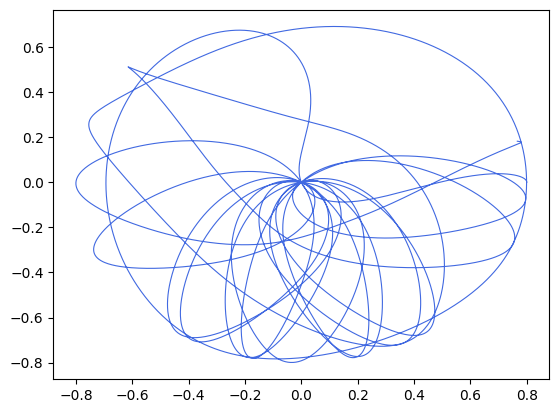

In [4]:
#The double pendulum
import numpy as np
import matplotlib.pyplot as plt


g=9.8
l=0.4
m=1.0


def f(r): #이중진자 운동방정식
  theta1,theta2,omega1,omega2=r[0],r[1],r[2],r[3]
  f1=omega1
  f2=omega2
  df1=-(omega1**2*np.sin(2*theta1-2*theta2)+2*omega2**2*np.sin(theta1-theta2)+(g/l)
  *(np.sin(theta1-2*theta2)+4*np.sin(theta1)))/(3-np.cos(2*theta1-2*theta2))
  df2=(4*omega1**2*np.sin(theta1-theta2)+omega2**2*np.sin(2*theta1-2*theta2)+2*(g/l)
  *(np.sin(2*theta1-theta2)+np.sin(theta2)))/(3-np.cos(2*theta1-2*theta2))
  return np.array([f1,f2,df1,df2],float)

def RK4(f,r,h):
  k1=h*f(r)
  k2=h*f(r+0.5*k1)
  k3=h*f(r+0.5*k2)
  k4=h*f(r+k3)
  r+=(k1+2*k2+2*k3+k4)/6
  return r

a=0.0
b=100.0
N=100000
h=(b-a)/N
tpoints=np.arange(a,b,h)
r=np.zeros((len(tpoints),4),float)
r[0]=np.array([90*np.pi/180,90*np.pi/180,0.0,0.0],float)
E_list=[]

for i in range(len(tpoints)-1):
   r[i+1]=RK4(f,r[i],h)


for j in range(len(tpoints)):
  E=m*l**2*(r[:,2][j]**2+0.5*r[:,3][j]**2+r[:,2][j]*r[:,3][j]
            *np.cos(r[:,0][j]-r[:,1][j]))-(m*g*l*(2*np.cos(r[:,0][j])
            +np.cos(r[:,1][j])))
  E_list.append(E)
x1=l*np.sin(r[:,0])
x2=x1+l*np.sin(r[:,1])
y1=-l*np.cos(r[:,0])
y2=y1-l*np.cos(r[:,1])

plt.plot(x2[:8000],y2[:8000],lw=0.8,color='royalblue')
plt.show()










In [10]:
#The double pendulum Animation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML



g=9.8
l=0.4
m=1.0


def f(r):
  theta1,theta2,omega1,omega2=r[0],r[1],r[2],r[3]
  f1=omega1
  f2=omega2
  df1=-(omega1**2*np.sin(2*theta1-2*theta2)+2*omega2**2*np.sin(theta1-theta2)+(g/l)
  *(np.sin(theta1-2*theta2)+4*np.sin(theta1)))/(3-np.cos(2*theta1-2*theta2))
  df2=(4*omega1**2*np.sin(theta1-theta2)+omega2**2*np.sin(2*theta1-2*theta2)+2*(g/l)
  *(np.sin(2*theta1-theta2)+np.sin(theta2)))/(3-np.cos(2*theta1-2*theta2))
  return np.array([f1,f2,df1,df2],float)

def RK4(f,r,h):
  k1=h*f(r)
  k2=h*f(r+0.5*k1)
  k3=h*f(r+0.5*k2)
  k4=h*f(r+k3)
  r+=(k1+2*k2+2*k3+k4)/6
  return r

a=0.0
b=100.0
N=10000
h=(b-a)/N
tpoints=np.arange(a,b,h)
r=np.zeros((len(tpoints),4),float)
r[0]=np.array([90*np.pi/180,90*np.pi/180,0.0,0.0],float)
E_list=[]

for i in range(len(tpoints)-1):
   r[i+1]=RK4(f,r[i],h)


x1=l*np.sin(r[:,0])
x2=x1+l*np.sin(r[:,1])
y1=-l*np.cos(r[:,0])
y2=y1-l*np.cos(r[:,1])

step=5
x1_anim=x1[::step]
y1_anim=y1[::step]
x2_anim=x2[::step]
y2_anim=y2[::step]

fig,ax=plt.subplots(figsize=(6,6))
ax.set_xlim(-2*l-0.1,2*l+0.1)
ax.set_ylim(-2*l-0.1,2*l+0.1)
line,=ax.plot([],[],'o-',color='blue')
trace,=ax.plot([],[],'-',color='red',alpha=0.5)
def init():
  line.set_data([],[])
  trace.set_data([],[])
  return line,trace
def animate(frame):
  thisx=[0,x1_anim[frame],x2_anim[frame]]
  thisy=[0,y1_anim[frame],y2_anim[frame]]
  line.set_data(thisx,thisy)
  trace.set_data(x2_anim[:frame],y2_anim[:frame])
  return line,trace

ani=FuncAnimation(fig, animate, init_func=init, frames=len(x1_anim), interval=80, blit=True)

plt.rcParams['animation.embed_limit'] = 2**128
plt.close(fig)
HTML(ani.to_html5_video())






